<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/geospatial/Practical%203%20Geospatial%20Data%20Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:green">Kwanda Mazibuko - stdnr: 1077167
</span>

# <span style="color:blue">Imputation and Further Data Processing - Focusing on Tin (New Sn)
</span>

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

## Basic Data Processing

In [106]:
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/geospatial/Merged_Chem.csv"
df_1 = pd.read_csv(url)
df_1.head()

,Unnamed: 0,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,New Ba,New Be,New Bi,New Ca,New Cd,New Ce,New Co,New Cr,New Cs,New Cu,New Dy,New Er,New Eu,New Fe,New Ga,New Gd,New Ge,New Hf,New Hg,New Ho,New In,New K,New La,New Li,New Lu,New Mg,New Mn,New Mo,New Na,New Nb,New Nd,New Ni,New P,New Pb,New Pd,New Pr,New Pt,New Rb,New Re,New S,New Sb,New Sc,New Se,New Sm,New Sn,New Sr,New Ta,New Tb,New Te,New Th,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,013L781002,013L,54.989093,-62.019071,40.0,38.0,NaN,43.0,10.0,NaN,70.0,1.00,NaN,2.0,85.0,23,40.0,0.3,Routine,013L,54.98900,-62.01995,57.0,2.89,NaN,1.0,NaN,81.5,0.2,0.02,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,NaN,0.03,46.0,0.23,NaN,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,NaN,2.84,NaN,1.6,NaN,0.25,NaN,2.3,0.7,1.90,0.1,41.0,NaN,0.20,NaN,0.8,0.021,0.03,0.10,0.3,31.0,NaN,6.04,0.64,44.0,0.9
2,2,013L781003,013L,54.975382,-62.030577,40.0,44.0,NaN,35.0,8.0,NaN,80.0,1.90,NaN,NaN,80.0,33,70.0,0.5,Routine,013L,54.97529,-62.03145,106.0,3.22,0.1,1.6,NaN,26.0,NaN,0.02,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,NaN,0.03,66.0,0.20,NaN,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,NaN,2.61,NaN,1.6,NaN,0.30,0.02,2.3,1.3,1.76,0.1,31.3,NaN,0.19,NaN,0.8,0.021,0.03,0.08,0.3,45.0,NaN,5.65,0.49,45.1,1.0
3,3,013L781004,013L,54.976331,-62.044913,46.0,30.0,NaN,34.0,8.0,NaN,80.0,0.70,NaN,2.0,90.0,27.2,50.0,0.6,Routine,013L,54.97623,-62.04579,59.0,2.34,0.1,1.1,NaN,49.9,0.1,0.03,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,NaN,0.03,51.0,0.28,NaN,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,NaN,3.22,NaN,1.7,NaN,0.27,0.04,2.2,0.7,2.20,0.1,40.9,NaN,0.22,NaN,0.7,0.023,0.04,0.09,0.3,17.0,NaN,7.19,0.64,51.4,0.8
4,4,013L781005,013L,54.973541,-62.054790,50.0,26.0,NaN,22.0,6.0,NaN,120.0,0.85,NaN,2.0,60.0,29.6,40.0,0.6,First Field Duplicate,013L,54.97344,-62.05566,70.0,2.26,0.1,0.9,NaN,20.3,0.2,NaN,0.47,0.29,17.2,6.4,14.0,0.13,26.07,1.47,0.78,0.71,0.84,3.2,1.82,NaN,0.02,51.0,0.28,NaN,0.02,12.2,1.8,0.12,0.14,94.0,0.79,0.072,0.37,13.24,26.1,0.051,1.55,NaN,3.37,NaN,1.1,NaN,0.35,NaN,2.1,0.6,2.05,0.1,28.2,NaN,0.26,NaN,0.6,0.014,0.03,0.12,0.6,34.0,NaN,8.08,0.74,51.1,0.8


In [107]:
df_1.columns

Index(['Unnamed: 0', 'Unique ID', 'NTS Sheet', 'Latitude_NAD83',
       'Longitude_NAD83', 'Old Zn', 'Old Cu', 'Old Pb', 'Old Ni', 'Old Co',
       'Old Ag', 'Old Mn', 'Old Fe', 'Old As', 'Old Mo', 'Old F', 'LOI',
       'Old Hg', 'Old U', 'Sample Type', 'NTS', 'Latitude (NAD 27)',
       'Longitude (NAD 27)', 'New Ag', 'New Al', 'New As', 'New Au', 'New B',
       'New Ba', 'New Be', 'New Bi', 'New Ca', 'New Cd', 'New Ce', 'New Co',
       'New Cr', 'New Cs', 'New Cu', 'New Dy', 'New Er', 'New Eu', 'New Fe',
       'New Ga', 'New Gd', 'New Ge', 'New Hf', 'New Hg', 'New Ho', 'New In',
       'New K', 'New La', 'New Li', 'New Lu', 'New Mg', 'New Mn', 'New Mo',
       'New Na', 'New Nb', 'New Nd', 'New Ni', 'New P', 'New Pb', 'New Pd',
       'New Pr', 'New Pt', 'New Rb', 'New Re', 'New S', 'New Sb', 'New Sc',
       'New Se', 'New Sm', 'New Sn', 'New Sr', 'New Ta', 'New Tb', 'New Te',
       'New Th', 'New Ti', 'New Tl', 'New Tm', 'New U', 'New V', 'New W',
       'New Y', 'New Yb', 'Ne

In [108]:
# df preprocessing
df = df_1.copy()
df = df.drop(index = 0)
df = df.drop(['Unnamed: 0'], axis = 1)
df.head()

,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,New Ba,New Be,New Bi,New Ca,New Cd,New Ce,New Co,New Cr,New Cs,New Cu,New Dy,New Er,New Eu,New Fe,New Ga,New Gd,New Ge,New Hf,New Hg,New Ho,New In,New K,New La,New Li,New Lu,New Mg,New Mn,New Mo,New Na,New Nb,New Nd,New Ni,New P,New Pb,New Pd,New Pr,New Pt,New Rb,New Re,New S,New Sb,New Sc,New Se,New Sm,New Sn,New Sr,New Ta,New Tb,New Te,New Th,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr
1,013L781002,013L,54.989093,-62.019071,40.0,38.0,NaN,43.0,10.0,NaN,70.0,1.00,NaN,2.0,85.0,23,40.0,0.3,Routine,013L,54.98900,-62.01995,57.0,2.89,NaN,1.0,NaN,81.5,0.2,0.02,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,NaN,0.03,46.0,0.23,NaN,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,NaN,2.84,NaN,1.6,NaN,0.25,NaN,2.3,0.7,1.90,0.1,41.0,NaN,0.20,NaN,0.8,0.021,0.03,0.10,0.3,31.0,NaN,6.04,0.64,44.0,0.9
2,013L781003,013L,54.975382,-62.030577,40.0,44.0,NaN,35.0,8.0,NaN,80.0,1.90,NaN,NaN,80.0,33,70.0,0.5,Routine,013L,54.97529,-62.03145,106.0,3.22,0.1,1.6,NaN,26.0,NaN,0.02,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,NaN,0.03,66.0,0.20,NaN,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,NaN,2.61,NaN,1.6,NaN,0.30,0.02,2.3,1.3,1.76,0.1,31.3,NaN,0.19,NaN,0.8,0.021,0.03,0.08,0.3,45.0,NaN,5.65,0.49,45.1,1.0
3,013L781004,013L,54.976331,-62.044913,46.0,30.0,NaN,34.0,8.0,NaN,80.0,0.70,NaN,2.0,90.0,27.2,50.0,0.6,Routine,013L,54.97623,-62.04579,59.0,2.34,0.1,1.1,NaN,49.9,0.1,0.03,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,NaN,0.03,51.0,0.28,NaN,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,NaN,3.22,NaN,1.7,NaN,0.27,0.04,2.2,0.7,2.20,0.1,40.9,NaN,0.22,NaN,0.7,0.023,0.04,0.09,0.3,17.0,NaN,7.19,0.64,51.4,0.8
4,013L781005,013L,54.973541,-62.054790,50.0,26.0,NaN,22.0,6.0,NaN,120.0,0.85,NaN,2.0,60.0,29.6,40.0,0.6,First Field Duplicate,013L,54.97344,-62.05566,70.0,2.26,0.1,0.9,NaN,20.3,0.2,NaN,0.47,0.29,17.2,6.4,14.0,0.13,26.07,1.47,0.78,0.71,0.84,3.2,1.82,NaN,0.02,51.0,0.28,NaN,0.02,12.2,1.8,0.12,0.14,94.0,0.79,0.072,0.37,13.24,26.1,0.051,1.55,NaN,3.37,NaN,1.1,NaN,0.35,NaN,2.1,0.6,2.05,0.1,28.2,NaN,0.26,NaN,0.6,0.014,0.03,0.12,0.6,34.0,NaN,8.08,0.74,51.1,0.8
5,013L781007,013L,54.936983,-62.026399,42.0,20.0,NaN,22.0,9.0,NaN,100.0,0.70,NaN,2.0,65.0,33.6,60.0,0.3,Routine,013L,54.93689,-62.02727,62.0,1.89,NaN,0.3,NaN,35.8,NaN,NaN,0.55,0.34,27.6,9.0,18.7,0.20,21.40,1.34,0.68,0.63,0.75,3.6,2.19,NaN,0.02,74.0,0.26,NaN,0.02,15.7,2.6,0.10,0.20,79.0,0.64,0.051,0.49,16.58,26.1,0.046,1.59,NaN,4.02,NaN,1.7,NaN,0.26,NaN,2.2,0.5,2.78,0.2,28.9,NaN,0.26,NaN,0.6,0.021,0.05,0.10,0.3,28.0,NaN,7.53,0.61,45.4,0.9


In [109]:
# Fixing LOI
df['LOI'] = np.abs(pd.to_numeric(df['LOI'], errors='coerce'))


In [110]:
# Next we will see how missing values affect our use. First, let's get a view of how much is missing.
df_stats = df.describe().T
df_stats.head()

,count,mean,std,min,25%,50%,75%,max
Latitude_NAD83,3441.0,55.383663,0.853529,54.005243,54.646363,55.238594,56.136332,56.997959
Longitude_NAD83,3441.0,-63.778378,1.451083,-66.997815,-64.884206,-63.316447,-62.667055,-62.001419
Old Zn,3441.0,111.829119,104.297344,14.000000,62.000000,90.000000,132.000000,2800.000000
Old Cu,3441.0,28.005522,23.771434,2.000000,14.000000,22.000000,34.000000,355.000000
Old Pb,2143.0,3.614559,2.526390,2.000000,2.000000,3.000000,4.000000,38.000000


In [111]:
# We want to plot the count vs. index, but we should make the index an actual column first
df_stats = df_stats.reset_index(drop = False) #we're keeping the old index
df_stats = df_stats.rename(columns = dict([['index', 'column']]))
df_stats.head()

,column,count,mean,std,min,25%,50%,75%,max
0,Latitude_NAD83,3441.0,55.383663,0.853529,54.005243,54.646363,55.238594,56.136332,56.997959
1,Longitude_NAD83,3441.0,-63.778378,1.451083,-66.997815,-64.884206,-63.316447,-62.667055,-62.001419
2,Old Zn,3441.0,111.829119,104.297344,14.000000,62.000000,90.000000,132.000000,2800.000000
3,Old Cu,3441.0,28.005522,23.771434,2.000000,14.000000,22.000000,34.000000,355.000000
4,Old Pb,2143.0,3.614559,2.526390,2.000000,2.000000,3.000000,4.000000,38.000000


In [112]:
# Let's create a list of elements again to facilitate this analysis
element_lst = [col for col in df.columns if ('Old') in col] + [col for col in df.columns if ('New') in col]

In [113]:
# Element List and Fraction of missing values
count_lst = []
for element in element_lst:

    count_lst.append([element, (df[element].isna().sum()/len(df))])


count_df = pd.DataFrame(count_lst, columns = ['Element', 'Fraction Missing'])
# sorting the dataframe
count_df = count_df.sort_values(by = 'Fraction Missing')

# our element of interest has 15% ,missing values
count_df[count_df['Element'].isin(['New Sn'])]

,Element,Fraction Missing
62,New Sn,0.154606


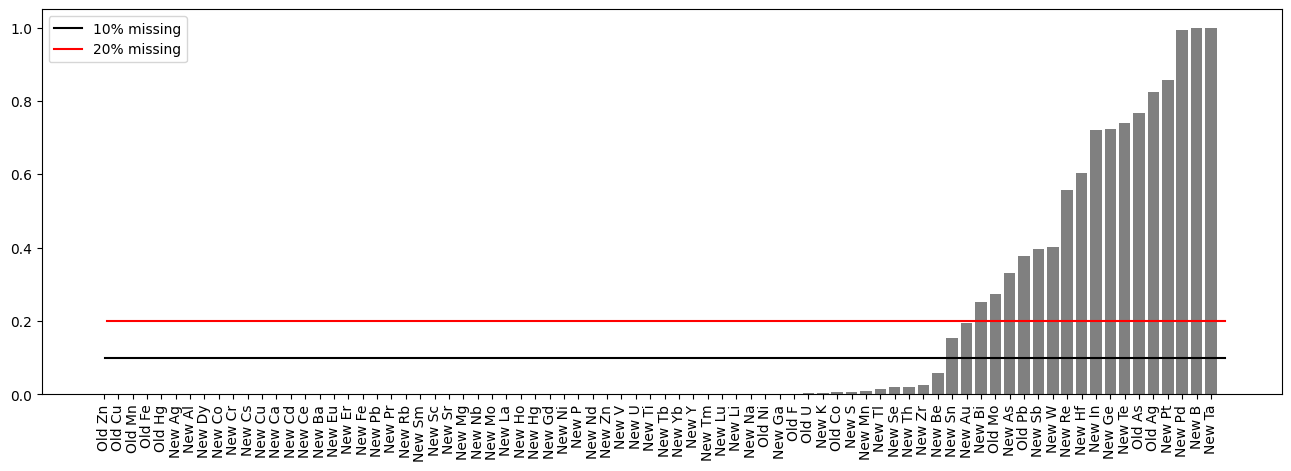

In [114]:
# Let's plot this
plt.figure(figsize = (16, 5))

plt.bar(count_df.Element, count_df['Fraction Missing'], color = 'grey')

plt.plot([len(count_df.Element), 0.1], [0.1, 0.1], color = 'black', label = '10% missing')
plt.plot([len(count_df.Element), 0.2], [0.2, 0.2], color = 'red', label = '20% missing')

plt.legend()
plt.xticks(rotation = 90)
plt.show()

- As seen that it is the first element above the 10% missing line. For elements to keep, we will include up to 16% to include our element of interest New Sn.

In [115]:
# Let's build a list of elements that we won't keep for futher processing
discard_elements = [element for element in element_lst if df[element].isna().sum()/len(df)>=0.16]

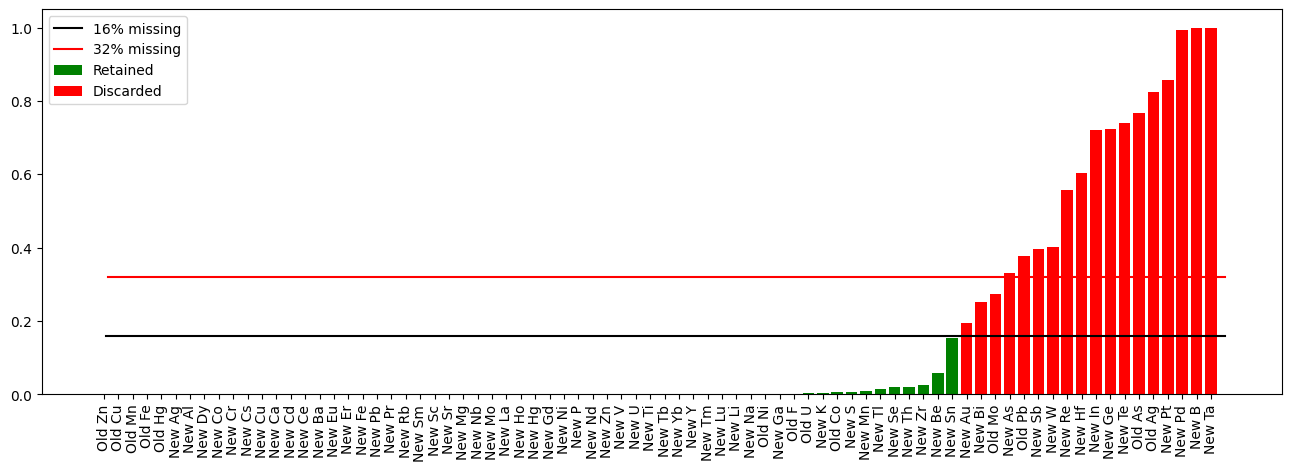

In [116]:
# Let's plot this
plt.figure(figsize = (16, 5))

plt.bar(count_df.Element, count_df['Fraction Missing'], color = 'green', label = 'Retained')

plt.bar(count_df[count_df.Element.isin(discard_elements)].Element,
        count_df[count_df.Element.isin(discard_elements)]['Fraction Missing'], color = 'red', label = 'Discarded')

plt.plot([len(count_df.Element), 0.16], [0.16, 0.16], color = 'black', label = '16% missing')
plt.plot([len(count_df.Element), 0.32], [0.32, 0.32], color = 'red', label = '32% missing')



plt.legend()
plt.xticks(rotation = 90)
plt.show()

- As seen that now we include New Sn which is our element of interest.

In [117]:
# We now reconstruct the list to create an updated list of elements
retained_elems = [element for element in element_lst if element not in discard_elements]


In [118]:
# we make our upper limit to 16% to include New Sn
demo_elements = [element for element in element_lst if (df[element].isna().sum()/len(df)>0.01) and (df[element].isna().sum()/len(df)<0.16)]
demo_elements

['New Be', 'New Mn', 'New Se', 'New Sn', 'New Th', 'New Tl', 'New Zr']

### Data Imputation

In [119]:
# KNNImputer

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors = 10)

In [120]:
# Let's create a list of names for imputed columns
imputed_elems = ['Imputed '+elem for elem in retained_elems]
df[imputed_elems] = pd.DataFrame(imputer.fit_transform(df[retained_elems]))
df.describe()

,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,New Ba,New Be,New Bi,New Ca,New Cd,New Ce,New Co,New Cr,New Cs,New Cu,New Dy,New Er,New Eu,New Fe,New Ga,New Gd,New Ge,New Hf,New Hg,New Ho,New In,New K,New La,New Li,New Lu,New Mg,New Mn,New Mo,New Na,New Nb,New Nd,New Ni,New P,New Pb,New Pd,New Pr,New Pt,New Rb,New Re,New S,New Sb,New Sc,New Se,New Sm,New Sn,New Sr,New Ta,New Tb,New Te,New Th,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr,Imputed Old Zn,Imputed Old Cu,Imputed Old Ni,Imputed Old Co,Imputed Old Mn,Imputed Old Fe,Imputed Old F,Imputed Old Hg,Imputed Old U,Imputed New Ag,Imputed New Al,Imputed New Ba,Imputed New Be,Imputed New Ca,Imputed New Cd,Imputed New Ce,Imputed New Co,Imputed New Cr,Imputed New Cs,Imputed New Cu,Imputed New Dy,Imputed New Er,Imputed New Eu,Imputed New Fe,Imputed New Ga,Imputed New Gd,Imputed New Hg,Imputed New Ho,Imputed New K,Imputed New La,Imputed New Li,Imputed New Lu,Imputed New Mg,Imputed New Mn,Imputed New Mo,Imputed New Na,Imputed New Nb,Imputed New Nd,Imputed New Ni,Imputed New P,Imputed New Pb,Imputed New Pr,Imputed New Rb,Imputed New S,Imputed New Sc,Imputed New Se,Imputed New Sm,Imputed New Sn,Imputed New Sr,Imputed New Tb,Imputed New Th,Imputed New Ti,Imputed New Tl,Imputed New Tm,Imputed New U,Imputed New V,Imputed New Y,Imputed New Yb,Imputed New Zn,Imputed New Zr
count,3441.000000,3441.000000,3441.000000,3441.000000,2143.000000,3438.000000,3416.000000,606.000000,3441.000000,3441.000000,799.000000,2496.000000,3433.000000,3436.000000,3441.000000,3430.000000,3441.000000,3441.000000,3440.000000,3440.000000,2298.000000,2772.000000,4.000000,3440.000000,3241.000000,2575.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3434.000000,3440.000000,948.000000,1369.000000,3440.000000,3440.000000,958.000000,3427.000000,3440.000000,3439.000000,3439.000000,3440.000000,3406.000000,3440.000000,3439.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,22.000000,3440.00000,490.000000,3440.000000,1524.000000,3414.000000,2079.000000,3440.000000,3373.000000,3440.000000,2909.000000,3440.000000,2.000000,3440.000000,897.000000,3368.000000,3440.000000,3393.000000,3439.000000,3440.000000,3440.000000,2056.000000,3440.000000,3440.000000,3440.000000,3355.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.00000
mean,55.383663,-63.778378,111.829119,28.005522,3.614559,17.569226,10.814110,0.278053,662.333333,2.686199,4.816646,6.525240,238.485290,25.832945,77.119442,3.542711,55.383561,-63.779213,175.697093,1.413776,3.125631,1.159848,22.500000,99.559273,0.731780,0.059814,0.365221,0.525137,120.534767,11.408692,24.931424,0.417125,29.778860,4.812532,2.521805,1.201087,2.659151,3.057076,6.551916,0.154536,0.084755,95.361628,0.908108,0.029081,0.076032,63.260233,6.745042,0.321093,0.244099,458.453611,5.655390,0.018914,1.128701,56.051834,22.909709,0.101501,4.739203,16.363636,15.38666,2.777551,6.815291,3.142388,0.333776,0.123959,2.904564,0.972902,8.835869,0.342970,23.004971,0.060000,0.870078,0.038874,2.501455,0.041443,0.138246,0.354181,3.464738,32.671221,0.438619,24.024858,2.199233,114.758692,1.785902,111

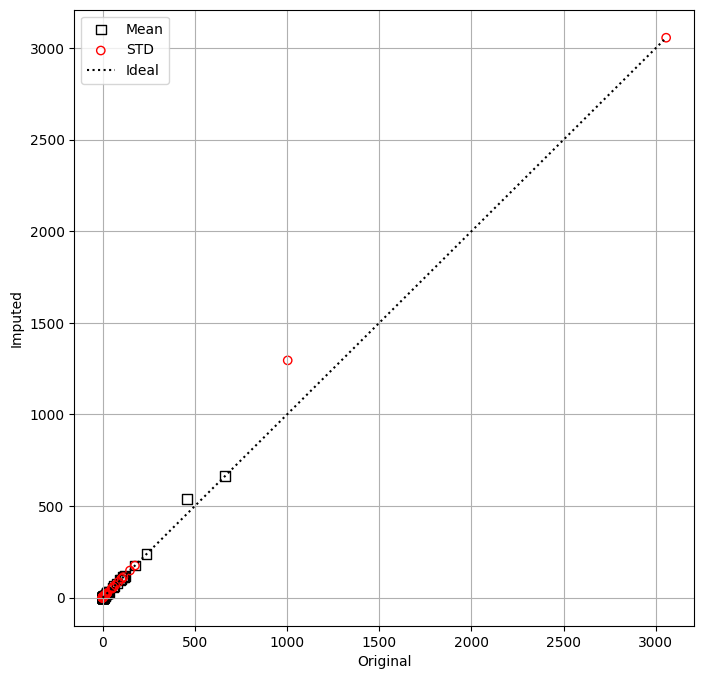

In [121]:
plt.figure(figsize = (8,8))


plt.scatter(df[retained_elems].mean(), df[imputed_elems].mean(),
            label = 'Mean', marker = 's', facecolor = 'none', edgecolor = 'black', s = 50)

plt.scatter(df[retained_elems].std(), df[imputed_elems].std(),
            label = 'STD', facecolor = 'none', edgecolor = 'red')

lim = max(max(df[retained_elems].mean()), max(df[imputed_elems].mean()), max(df[retained_elems].std()), max(df[imputed_elems].std()))


plt.plot([0,lim],[0,lim], linestyle = ':', color = 'k', label = 'Ideal')



plt.legend()
plt.xlabel('Original')
plt.ylabel('Imputed')
plt.grid()
plt.show()

In [122]:
from sklearn.metrics import r2_score


r2_lst = []


for n in range(1, 100, 1):


    imputer = KNNImputer(n_neighbors=n, weights = 'distance')



    df[imputed_elems] = pd.DataFrame(imputer.fit_transform(df[retained_elems]), columns = retained_elems)



    r2_lst.append([n, r2_score(df[retained_elems].mean(), df[imputed_elems].mean()), r2_score(df[retained_elems].std(), df[imputed_elems].std())])

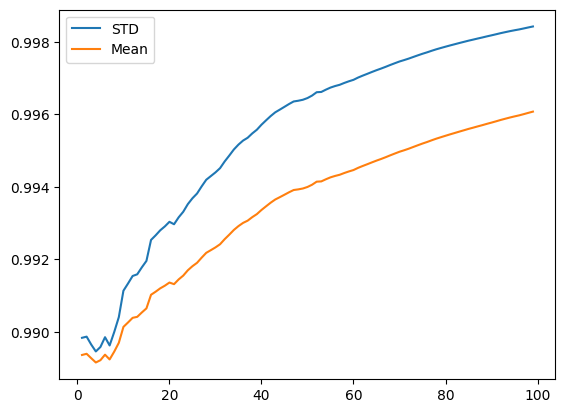

In [123]:
r2_df = pd.DataFrame(r2_lst, columns = ['N', 'Mean', 'STD'])
plt.plot(r2_df.N, r2_df.STD, label = 'STD')
plt.plot(r2_df.N, r2_df.Mean, label = 'Mean')
plt.legend()


(array([483.,   0., 808., 606.,   0.,   0., 431.,   0., 239.,   0., 135.,
         63.,   0.,   0.,  40.,   0.,  30.,   0.,  15.,   0.,   8.,   7.,
          0.,   7.,   0.,   3.,   0.,   4.,   0.,   0.,   2.,   4.,   0.,
          1.,   0.,   0.,   0.,   0.,   4.,   0.,   1.,   0.,   2.,   1.,
          0.,   4.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          2.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
        0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 , 1.15,
        1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 , 1.65, 1.7 ,
        1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15, 2.2 , 2.25,
        2.3 , 2.35, 2.

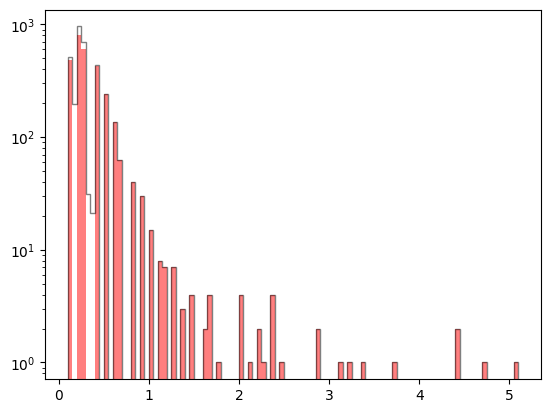

In [124]:
plt.hist(df['Imputed New Sn'], bins = 100, alpha = 0.5, histtype = 'step', log = True, color = 'k')
plt.hist(df['New Sn'], bins = 100, alpha = 0.5, log = True, color = 'red')

In [125]:
chemical = 'New Sn'

In [126]:
r2_lst = []

for n in range(1, 100, 1):

    imputer = KNNImputer(n_neighbors=n, weights = 'distance')

    df[imputed_elems] = pd.DataFrame(imputer.fit_transform(df[retained_elems]), columns = retained_elems)

    imput_hist = plt.hist(df[imputed_elems[retained_elems.index(chemical)]], bins = 100, log = True)
    orig_hist = plt.hist(df[chemical].dropna(), bins = 100, range = (df[imputed_elems[retained_elems.index(chemical)]].min(), df[imputed_elems[retained_elems.index(chemical)]].max()), log = True)



    plt.close()
    r2_lst.append([n, r2_score(orig_hist[0], imput_hist[0])])


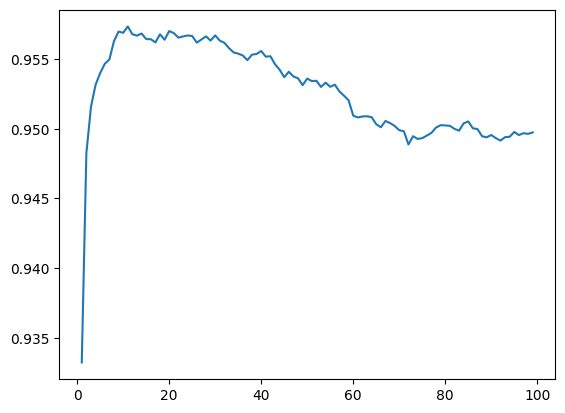

In [127]:
r2_df = pd.DataFrame(r2_lst, columns = ['N', 'R2'])


plt.plot(r2_df.N, r2_df.R2)


In [128]:
r2_df.R2.max()

0.9573456308648844

In [129]:
r2_df[r2_df.R2 == r2_df.R2.max()]

,N,R2
10,11,0.957346


In [130]:
imputer = KNNImputer(n_neighbors = 11, weights = 'distance')



df[imputed_elems] = pd.DataFrame(imputer.fit_transform(df[retained_elems]), columns = retained_elems)



df.describe()

,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,New Ba,New Be,New Bi,New Ca,New Cd,New Ce,New Co,New Cr,New Cs,New Cu,New Dy,New Er,New Eu,New Fe,New Ga,New Gd,New Ge,New Hf,New Hg,New Ho,New In,New K,New La,New Li,New Lu,New Mg,New Mn,New Mo,New Na,New Nb,New Nd,New Ni,New P,New Pb,New Pd,New Pr,New Pt,New Rb,New Re,New S,New Sb,New Sc,New Se,New Sm,New Sn,New Sr,New Ta,New Tb,New Te,New Th,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr,Imputed Old Zn,Imputed Old Cu,Imputed Old Ni,Imputed Old Co,Imputed Old Mn,Imputed Old Fe,Imputed Old F,Imputed Old Hg,Imputed Old U,Imputed New Ag,Imputed New Al,Imputed New Ba,Imputed New Be,Imputed New Ca,Imputed New Cd,Imputed New Ce,Imputed New Co,Imputed New Cr,Imputed New Cs,Imputed New Cu,Imputed New Dy,Imputed New Er,Imputed New Eu,Imputed New Fe,Imputed New Ga,Imputed New Gd,Imputed New Hg,Imputed New Ho,Imputed New K,Imputed New La,Imputed New Li,Imputed New Lu,Imputed New Mg,Imputed New Mn,Imputed New Mo,Imputed New Na,Imputed New Nb,Imputed New Nd,Imputed New Ni,Imputed New P,Imputed New Pb,Imputed New Pr,Imputed New Rb,Imputed New S,Imputed New Sc,Imputed New Se,Imputed New Sm,Imputed New Sn,Imputed New Sr,Imputed New Tb,Imputed New Th,Imputed New Ti,Imputed New Tl,Imputed New Tm,Imputed New U,Imputed New V,Imputed New Y,Imputed New Yb,Imputed New Zn,Imputed New Zr
count,3441.000000,3441.000000,3441.000000,3441.000000,2143.000000,3438.000000,3416.000000,606.000000,3441.000000,3441.000000,799.000000,2496.000000,3433.000000,3436.000000,3441.000000,3430.000000,3441.000000,3441.000000,3440.000000,3440.000000,2298.000000,2772.000000,4.000000,3440.000000,3241.000000,2575.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3434.000000,3440.000000,948.000000,1369.000000,3440.000000,3440.000000,958.000000,3427.000000,3440.000000,3439.000000,3439.000000,3440.000000,3406.000000,3440.000000,3439.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,22.000000,3440.00000,490.000000,3440.000000,1524.000000,3414.000000,2079.000000,3440.000000,3373.000000,3440.000000,2909.000000,3440.000000,2.000000,3440.000000,897.000000,3368.000000,3440.000000,3393.000000,3439.000000,3440.000000,3440.000000,2056.000000,3440.000000,3440.000000,3440.000000,3355.000000,3440.000000,3440.000000,3440.00000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.00000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000
mean,55.383663,-63.778378,111.829119,28.005522,3.614559,17.569226,10.814110,0.278053,662.333333,2.686199,4.816646,6.525240,238.485290,25.832945,77.119442,3.542711,55.383561,-63.779213,175.697093,1.413776,3.125631,1.159848,22.500000,99.559273,0.731780,0.059814,0.365221,0.525137,120.534767,11.408692,24.931424,0.417125,29.778860,4.812532,2.521805,1.201087,2.659151,3.057076,6.551916,0.154536,0.084755,95.361628,0.908108,0.029081,0.076032,63.260233,6.745042,0.321093,0.244099,458.453611,5.655390,0.018914,1.128701,56.051834,22.909709,0.101501,4.739203,16.363636,15.38666,2.777551,6.815291,3.142388,0.333776,0.123959,2.904564,0.972902,8.835869,0.342970,23.004971,0.060000,0.870078,0.038874,2.501455,0.041443,0.138246,0.354181,3.464738,32.671221,0.438619,24.024858,2.199233,114.758692,1.785902,111.

In [131]:
orig_hist[0]

array([483.,   0., 808., 606.,   0.,   0., 431.,   0., 239.,   0., 135.,
        63.,   0.,   0.,  40.,   0.,  30.,   0.,  15.,   0.,   8.,   7.,
         0.,   7.,   0.,   3.,   0.,   4.,   0.,   0.,   2.,   4.,   0.,
         1.,   0.,   0.,   0.,   0.,   4.,   0.,   1.,   0.,   2.,   1.,
         0.,   4.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         2.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   1.,
         0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,
         0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
         1.])

In [133]:
imput_hist = np.histogram(df[imputed_elems[retained_elems.index(chemical)]], bins = 100)
orig_hist = np.histogram(df[chemical].dropna(), bins = 100, range = (df[imputed_elems[retained_elems.index(chemical)]].min(), df[imputed_elems[retained_elems.index(chemical)]].max()))

lim = max(max(imput_hist[0]), max(orig_hist[0]))
plt.plot([0,lim],[0,lim], linestyle = ':', color = 'purple', label = 'Ideal')

plt.scatter(imput_hist[0], orig_hist[0])

ValueError: autodetected range of [nan, nan] is not finite

In [ ]:


figs_col = 4

num_rows = int(np.ceil(len(retained_elems)/figs_col))
fig_size = 4


fig, axes = plt.subplots(num_rows, figs_col, figsize = (fig_size*figs_col, fig_size*num_rows))

i=0


colormap1=plt.cm.get_cmap('jet_r', len(retained_elems))
colormap2=plt.cm.get_cmap('jet', len(retained_elems))

for chemical in retained_elems:
    ax = axes[i//4, i%4]

    ax.hist(df[chemical], bins = 100, color = colormap1(i),
            label = chemical+' Original', log = True)
    ax.hist(df[imputed_elems[retained_elems.index(chemical)]], bins = 100, color = colormap2(i),
            label = chemical+' Imputed', log = True, histtype = 'step')

    i = i+1


    ax.legend()
    ax.grid()


plt.show()

In [ ]:
imputed_demo_elements = ['Imputed '+element for element in demo_elements]
imputed_demo_elements

In [ ]:
for element in demo_elements:
    print(element, imputed_demo_elements[demo_elements.index(element)])
    temp_df = df[df[element].isna()][imputed_demo_elements[demo_elements.index(element)]]


    print(temp_df.mean())

In [ ]:
plt.hist(df['Imputed New Sn'], log = True)
plt.hist(df['New Sn'], histtype = 'step', log = True)

### Outlier Analysis

In [ ]:
df

## Element of Focus - Tin (Sn)

In [ ]:
# Let's take a look at one element - "Sn" for now

plt.hist(df['Imputed New Sn'], bins = 100, log = True) #enabling log helps, why?
plt.show()

### Assignment


#### Impute over the "New Sn" analysis. Optimize it using the distribution (histogram) + R2 metric based method. Then visualize your results the same way we did here for the demo elements.

What is the best number of neighbours for "New Sn"? Is it obvious?